In [1]:
# --- Setup and Installations ---
!pip install --upgrade yfinance yahoofinancials requests urllib3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 31.1 MB/s eta 0:00:00
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=b794cabb15e0ca6a5c5bdded4f533fcac68747e06953d68eaf750c7cdc088749
  Stored in directory: /root/.cache/pip/wheels/b0/e1/ca/e683b02e57db550881c8ebb89ba3eccb7a5c0ebfad7f03acea
Successfully built yahoofinancials
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstallin

In [2]:
# --- Imports ---
import pandas as pd
import yfinance as yf
from yahoofinancials import YahooFinancials
import requests
from io import StringIO
from IPython.display import display
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

In [3]:
# TASK 1: Extract and store the S&P 500 Tickers
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
response.raise_for_status()

# Read all tables on the page
tables = pd.read_html(StringIO(response.text))

# Find the table that contains a 'Symbol' column
sp500_table = None
for table in tables:
    cols_lower = [str(c).lower() for c in table.columns]
    if "symbol" in cols_lower:
        sp500_table = table.copy()
        break

if sp500_table is None:
    raise ValueError("No table with a 'Symbol' column found on the page.")

# Standardise column name to 'Symbol'
for col in sp500_table.columns:
    if str(col).lower() == "symbol":
        symbol_col = col
        break

sp500_table.rename(columns={symbol_col: "Symbol"}, inplace=True)

# Clean tickers (BRK.B → BRK-B) for Yahoo Finance
sp500_table["Symbol"] = (
    sp500_table["Symbol"]
    .astype(str)
    .str.replace(".", "-", regex=False)
)

In [4]:
# FINAL LIST OF TICKERS
tickers = sp500_table["Symbol"].unique().tolist()
print("Task 1 Complete: Number of tickers extracted:", len(tickers))

#Relevant code and extracted list of tickers
print("Extracted Tickers List:", tickers)


Task 1 Complete: Number of tickers extracted: 503
Extracted Tickers List: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BK', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'CPB', 'COF', 'CAH', 'CCL', 'CARR', 'CVNA', 'CASY', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CIEN', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COHR', 'COIN', 'CL', 'CMCSA', 'FIX', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 

In [5]:
# TASK 2: Load S&P 500 Tickers daily market performance (01-01-2022 to 01-01-2025)
start_date = "2022-01-01"
end_date = "2025-01-01"

print("\nTask 2: Downloading raw historical data (All Metrics)...")
# Gets Adj Close
market_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)

# Provide the extracted data size and dimensionality
print(f"Task 2 Complete: Raw Data Shape: {market_data.shape}")
print(f"Total elements in landing zone: {market_data.size}")
display(market_data.head())


Task 2: Downloading raw historical data (All Metrics)...


[****************      34%                       ]  172 of 503 completedERROR:yfinance:$Q: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")
[**********************81%**************         ]  409 of 503 completedERROR:yfinance:$SNDK: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")
[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['Q', 'SNDK']: possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1641013200, endDate = 1735707600")


Task 2 Complete: Raw Data Shape: (753, 3018)
Total elements in landing zone: 2272554


Price        Adj Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  151.702133  178.103668  115.847206  172.679993  128.346008   
2022-01-04  146.573654  175.843231  115.624809  170.800003  125.327515   
2022-01-05  144.062775  171.165817  116.232178  162.250000  124.764435   
2022-01-06  144.566864  168.308533  115.684662  159.750000  124.745979   
2022-01-07  140.718109  168.474854  115.385269  166.050003  125.133652   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  380.485260  564.369995  164.526459  60.037262  ...   
2022-01-04  42.914051  377.766235  554.000000  163.040466  61.151535  ...   
2022-01-05  42.410072  371.113556  514.429993  160.523560  60.673985  ...   
2022-01-06  42.657307  353.192261  514.119995  161.034409  61.213428  ...   
2022-01-07  42.856995  346.418121  510.700012  156.808655  61.735184  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  

[5 rows x 3018 columns]

In [6]:
market_data

Price        Adj Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  151.702133  178.103668  115.847206  172.679993  128.346008   
2022-01-04  146.573654  175.843231  115.624809  170.800003  125.327515   
2022-01-05  144.062775  171.165817  116.232178  162.250000  124.764435   
2022-01-06  144.566864  168.308533  115.684662  159.750000  124.745979   
2022-01-07  140.718109  168.474854  115.385269  166.050003  125.133652   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457260  256.797211  172.530685  134.990005  112.058296   
2024-12-26  134.190521  257.612732  171.763870  135.320007  112.556290   
2024-12-27  133.904007  254.201370  170.623245  133.384995  112.282875   
2024-12-30  132.797516  250.829773  168.888367  131.809998  110.144440   
2024-12-31  132.963791  249.059464  170.326096  131.410004  110.447136   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  380.485260  564.369995  164.526459  60.037262  ...   
2022-01-04  42.914051  377.766235  554.000000  163.040466  61.151535  ...   
2022-01-05  42.410072  371.113556  514.429993  160.523560  60.673985  ...   
2022-01-06  42.657307  353.192261  514.119995  161.034409  61.213428  ...   
2022-01-07  42.856995  346.418121  510.700012  156.808655  61.735184  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  353.541473  447.940002  213.882050  48.364082  ...   
2024-12-26  92.930000  352.368317  450.160004  213.852631  48.344978  ...   
2024-12-27  92.339996  348.213348  446.480011  212.803284  48.316326  ...   
2024-12-30  91.889999  344.605927  445.799988  208.458740  47.829144  ...   
2024-12-31  92.349998  343.921600  444.679993  208.360703  48.259003  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[753 rows x 3018 columns]

In [7]:
# TASK 3: Identify and remove invalid data

# 1. Identify tickers with ANY missing data in the 'Close' column
# We slice into 'Close' to find the specific ticker names with NaNs
missing_data_mask = market_data['Close'].isnull().any()
tickers_to_remove = missing_data_mask[missing_data_mask].index.tolist()

print(f"Tickers identified for removal: {len(tickers_to_remove)}")

# 2. Remove these tickers from the entire warehouse (Level 1)
clean_data = market_data.drop(labels=tickers_to_remove, axis=1, level=1)

# 3. Final alignment: Drop dates if the entire market was closed (holidays)
clean_data = clean_data.dropna(axis=0, how='all')

print("-" * 30)
print(f"Task 3 Complete: Full ETL Cleanup")
print(f"Cleaned Dimensionality (Rows, Columns): {clean_data.shape}")
print(f"Total Surviving Tickers: {clean_data.shape[1] // 5}") # Based on 5 attributes
print("-" * 30)

Tickers identified for removal: 8
------------------------------
Task 3 Complete: Full ETL Cleanup
Cleaned Dimensionality (Rows, Columns): (753, 2970)
Total Surviving Tickers: 594
------------------------------


In [8]:
clean_data

Price        Adj Close                                                  \
Ticker               A        AAPL        ABBV        ABNB         ABT   
Date                                                                     
2022-01-03  151.702133  178.103668  115.847206  172.679993  128.346008   
2022-01-04  146.573654  175.843231  115.624809  170.800003  125.327515   
2022-01-05  144.062775  171.165817  116.232178  162.250000  124.764435   
2022-01-06  144.566864  168.308533  115.684662  159.750000  124.745979   
2022-01-07  140.718109  168.474854  115.385269  166.050003  125.133652   
...                ...         ...         ...         ...         ...   
2024-12-24  134.457260  256.797211  172.530685  134.990005  112.058296   
2024-12-26  134.190521  257.612732  171.763870  135.320007  112.556290   
2024-12-27  133.904007  254.201370  170.623245  133.384995  112.282875   
2024-12-30  132.797516  250.829773  168.888367  131.809998  110.144440   
2024-12-31  132.963791  249.059464  170.326096  131.410004  110.447136   

Price                                                                 ...  \
Ticker           ACGL         ACN        ADBE         ADI        ADM  ...   
Date                                                                  ...   
2022-01-03  42.362530  380.485260  564.369995  164.526459  60.037262  ...   
2022-01-04  42.914051  377.766235  554.000000  163.040466  61.151535  ...   
2022-01-05  42.410072  371.113556  514.429993  160.523560  60.673985  ...   
2022-01-06  42.657307  353.192261  514.119995  161.034409  61.213428  ...   
2022-01-07  42.856995  346.418121  510.700012  156.808655  61.735184  ...   
...               ...         ...         ...         ...        ...  ...   
2024-12-24  92.669998  353.541473  447.940002  213.882050  48.364082  ...   
2024-12-26  92.930000  352.368317  450.160004  213.852631  48.344978  ...   
2024-12-27  92.339996  348.213348  446.480011  212.803284  48.316326  ...   
2024-12-30  91.889999  344.605927  445.799988  208.458740  47.829144  ...   
2024-12-31  92.349998  343.921600  444.679993  208.360703  48.259003  ...   

Price        Volume                                                          \
Ticker           WY     WYNN      XEL       XOM      XYL       XYZ      YUM   
Date                                                                          
2022-01-03  3831100  2437800  3501100  24282400   759100   7315700  1251400   
2022-01-04  3089700  2292300  4197000  38584000   925400  14768500   935900   
2022-01-05  3737600  3439900  4166000  34033300  1090200  17546200   977900   
2022-01-06  3315200  2583200  2296000  30668500   703400  16244200   862400   
2022-01-07  3309900  1720400  2673100  23985400   765000   9426000   833700   
...             ...      ...      ...       ...      ...       ...      ...   
2024-12-24  1780100   692800   943900   7807000   379300   2197700   533000   
2024-12-26  1736500  1218900  1394900   9652400   575700   2991100  1040900   
2024-12-27  2320500  1086700  2015000  11943900   552400   4140800  1146300   
2024-12-30  2914700  2180100  2642900  11080800   586800   5383800  1144600   
2024-12-31  3125200  1612600  2143800  12387800   641600   4989400  1217100   

Price                                 
Ticker          ZBH    ZBRA      ZTS  
Date                                  
2022-01-03  1184809  272600  2772700  
2022-01-04  1400800  346000  4664000  
2022-01-05  1895715  403700  4749400  
2022-01-06  1088813  338300  3103400  
2022-01-07  1690230  432800  2206500  
...             ...     ...      ...  
2024-12-24   458600   88700  1023600  
2024-12-26  1277300  140100  2167200  
2024-12-27   743400  287200  1800100  
2024-12-30  1532000  211300  1531400  
2024-12-31   683300  327900  1327400  

[753 rows x 2970 columns]

In [9]:
import numpy as np
import pandas as pd
import yfinance as yf

# CONFIGURATION
RISK_FREE_RATE = 0.0  # Set to 0.02 for a 2% risk-free rate assumption

def calculate_ratios(returns, benchmark_returns, rf_rate=0.0):
    # Task 5: Beta
    beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)

    # Task 6: Annual Volatility
    vol = np.std(returns) * np.sqrt(252)

    # Annualized Return
    ann_ret = np.mean(returns) * 252

    # NEW: Sharpe Ratio
    # We subtract the risk-free rate from the return and divide by volatility
    sharpe = (ann_ret - rf_rate) / vol if vol != 0 else 0

    return beta, vol, ann_ret, sharpe

def build_ultimate_screener(clean_df, tickers_list, index='^GSPC', start="2022-01-01", end="2025-01-01"):
    available_prices = clean_df.columns.levels[0]
    price_type = 'Adj Close' if 'Adj Close' in available_prices else 'Close'

    df = clean_df[price_type].copy()
    benchmark_raw = yf.download(index, start=start, end=end)
    benchmark_data = benchmark_raw[price_type] if price_type in benchmark_raw.columns else benchmark_raw.iloc[:, 0]
    df[index] = benchmark_data

    # Task 4: Daily Return for Benchmark
    benchmark_ret = df[index].pct_change().dropna()
    results = []

    for ticker in tickers_list:
        if ticker in df.columns and ticker != index:
            # Task 4: Daily Return for Stock
            ret = df[ticker].pct_change().dropna()
            aligned = pd.concat([ret, benchmark_ret], axis=1, join='inner').dropna()

            if not aligned.empty:
                # Calculate all metrics including Sharpe
                beta, vol, ann_ret, sharpe = calculate_ratios(aligned.iloc[:, 0], aligned.iloc[:, 1], rf_rate=RISK_FREE_RATE)

                results.append({
                    'Ticker': ticker,
                    'Beta': beta,
                    'Annual Volatility': vol,
                    'Annualized Return': ann_ret,
                    'Sharpe Ratio': sharpe
                })

    return pd.DataFrame(results)

# --- Execution ---
print(f"Calculating Risk-Adjusted Metrics (RF Rate: {RISK_FREE_RATE})...")
final_metrics_df = build_ultimate_screener(clean_data, tickers)

display(final_metrics_df.sort_values(by='Sharpe Ratio', ascending=False).head(10))

Calculating Risk-Adjusted Metrics (RF Rate: 0.0)...


[*********************100%***********************]  1 of 1 completed


,Ticker,Beta,Annual Volatility,Annualized Return,Sharpe Ratio
468,VST,1.005323,0.419073,0.714812,1.705699
171,EME,0.894448,0.288966,0.471579,1.631954
427,TRGP,0.885100,0.310812,0.476837,1.534167
194,FICO,1.249708,0.374449,0.571252,1.525579
237,HWM,1.094029,0.305800,0.458003,1.497722
121,FIX,1.217590,0.388074,0.570468,1.469998
285,LLY,0.576461,0.287664,0.401066,1.394217
85,CAH,0.421336,0.234304,0.325826,1.390613
485,WMB,0.603023,0.228920,0.315634,1.378793
303,MCK,0.289306,0.233707,0.311816,1.334218


In [10]:
#TASK 4,5,6

def calculate_ratios(returns, benchmark_returns):
    # Task 5: Beta Calculation
    beta = np.cov(returns, benchmark_returns)[0,1] / np.var(benchmark_returns)

    # Task 6: Annual Volatility Calculation (Daily Standard Deviation * sqrt(252))
    annual_volatility = np.std(returns) * np.sqrt(252)

    # Annualized Return
    ann_ret = np.mean(returns) * 252

    return beta, annual_volatility, ann_ret

def build_screener_from_clean(clean_df, tickers_list, index='^GSPC', start="2022-01-01", end="2025-01-01"):
    df = clean_df['Close'].copy()

    # 2. Download ONLY the benchmark data (S&P 500) for the matching timeframe
    print(f"Fetching benchmark data for {index}...")
    benchmark_data = yf.download(index, start=start, end=end)['Close']

    # 3. Merge the benchmark into the flattened stock dataset
    df[index] = benchmark_data

    # Task 4: Daily Return for the Benchmark
    benchmark = df[index].pct_change().dropna()
    results = []

    for ticker in tickers_list:
        # Safety check to ensure the ticker actually exists in our clean_data
        if ticker in df.columns and ticker != index:
            # Task 4: Daily Return for the Stock
            ret = df[ticker].pct_change().dropna()

            # Align dates so stock and benchmark match perfectly (Inner Join)
            aligned = pd.concat([ret, benchmark], axis=1, join='inner').dropna()

            # Tasks 5 & 6: Calculate the metrics
            beta, annual_vol,ann_ret = calculate_ratios(aligned[ticker], aligned[index])

            results.append({
                'Ticker': ticker,
                'Beta': beta,
                'Annual Volatility': annual_vol,
                'Annualized Return': ann_ret
            })

    return pd.DataFrame(results)

# --- Execution ---
print("\nTasks 4, 5 & 6: Calculating metrics directly from clean_data...")

# Execute the function using your existing clean_data and tickers variables
final_metrics_df = build_screener_from_clean(clean_data, tickers)

print("Calculations Complete. Final Metrics Data Shape:", final_metrics_df.shape)
display(final_metrics_df.head())

[*********************100%***********************]  1 of 1 completed


Tasks 4, 5 & 6: Calculating metrics directly from clean_data...
Fetching benchmark data for ^GSPC...


Calculations Complete. Final Metrics Data Shape: (495, 4)


,Ticker,Beta,Annual Volatility,Annualized Return
0,MMM,0.790522,0.296581,-0.004252
1,AOS,0.920267,0.278284,-0.029500
2,ABT,0.672282,0.218008,-0.045408
3,ABBV,0.297552,0.221606,0.115981
4,ACN,1.095940,0.270146,-0.012487


In [11]:
# Check the first ticker's prices
first_ticker = clean_data['Close'].columns[0]
sample_price = clean_data['Close'][first_ticker].iloc[0]

# If there are more than 2 decimal places, it's adjusted!
if round(sample_price, 2) != sample_price:
    print(f"CONFIRMED: Your 'Close' column is already Adjusted Close (Value: {sample_price})")
else:
    print("Your 'Close' column appears to be raw prices.")

CONFIRMED: Your 'Close' column is already Adjusted Close (Value: 156.47999572753906)


In [12]:
final_metrics_df

,Ticker,Beta,Annual Volatility,Annualized Return
0,MMM,0.790522,0.296581,-0.004252
1,AOS,0.920267,0.278284,-0.029500
2,ABT,0.672282,0.218008,-0.045408
3,ABBV,0.297552,0.221606,0.115981
4,ACN,1.095940,0.270146,-0.012487
...,...,...,...,...
490,XYL,1.069216,0.272758,0.034917
491,YUM,0.635727,0.191280,0.012455
492,ZBRA,1.502187,0.399784,-0.057525
493,ZBH,0.736912,0.244781,-0.027370


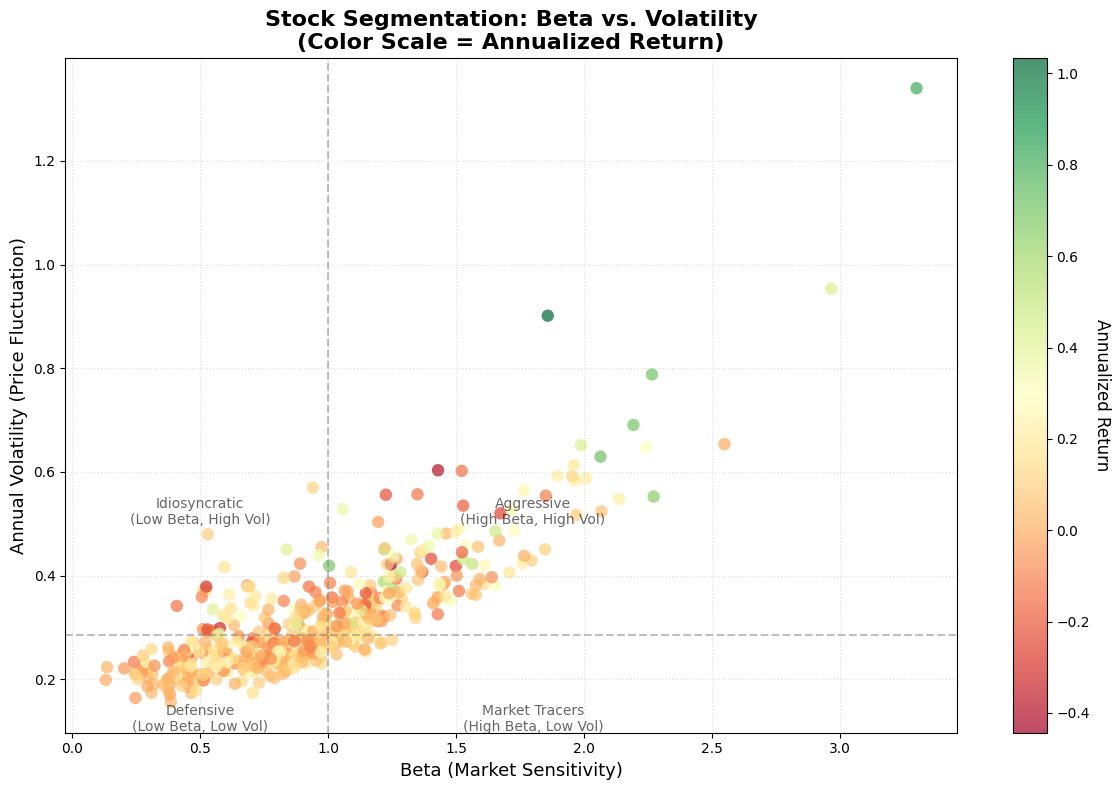

In [13]:
# TASK 7

# 1. Create the Visualization
plt.figure(figsize=(12, 8))

# We plot Beta vs Volatility and use 'c' to map Annualized Return to color
scatter = plt.scatter(
    final_metrics_df['Beta'],
    final_metrics_df['Annual Volatility'],
    c=final_metrics_df['Annualized Return'],
    cmap='RdYlGn',           # Green = High Return, Red = Low/Negative Return
    alpha=0.7,
    edgecolors='none',
    s=80                     # Size of the bubbles
)

# 2. Add a Color Bar (to show what the colors mean)
cbar = plt.colorbar(scatter)
cbar.set_label('Annualized Return', rotation=270, labelpad=15, fontsize=12)

# 3. Add Quadrant Reference Lines
plt.axvline(x=1.0, color='grey', linestyle='--', alpha=0.5, label='Market Beta (1.0)')
plt.axhline(y=final_metrics_df['Annual Volatility'].median(), color='grey', linestyle='--', alpha=0.5, label='Median Volatility')

# 4. Labels and Title
plt.title('Stock Segmentation: Beta vs. Volatility\n(Color Scale = Annualized Return)', fontsize=16, fontweight='bold')
plt.xlabel('Beta (Market Sensitivity)', fontsize=13)
plt.ylabel('Annual Volatility (Price Fluctuation)', fontsize=13)

# 5. Add Text Labels for the Segments
plt.text(0.5, 0.5, 'Idiosyncratic\n(Low Beta, High Vol)', alpha=0.6, ha='center')
plt.text(1.8, 0.5, 'Aggressive\n(High Beta, High Vol)', alpha=0.6, ha='center')
plt.text(0.5, 0.1, 'Defensive\n(Low Beta, Low Vol)', alpha=0.6, ha='center')
plt.text(1.8, 0.1, 'Market Tracers\n(High Beta, Low Vol)', alpha=0.6, ha='center')

plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

In [14]:
!pip install -q scikit-learn scipy seaborn

In [15]:
# ── CELL 2: Imports ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


In [16]:
# ── CELL 3: Prepare Feature Matrix ────────────────────────────────────────
FEATURES = ['Annualized Return', 'Beta', 'Annual Volatility']
X_raw = final_metrics_df[FEATURES].dropna()
df = final_metrics_df.loc[X_raw.index].copy()

print(f'Feature matrix shape: {X_raw.shape}')
display(X_raw.describe())

Feature matrix shape: (495, 3)


,Annualized Return,Beta,Annual Volatility
count,495.000000,495.000000,495.000000
mean,0.090762,0.944521,0.314095
std,0.169397,0.432892,0.114602
min,-0.443186,0.131285,0.155972
25%,-0.011043,0.633453,0.240144
50%,0.075602,0.909964,0.284730
75%,0.179233,1.156209,0.357225
max,1.034712,3.298454,1.340147


In [17]:
# ── CELL 4: Skewness Check + Log Transform + Standard Scaling ─────────────
print('Skewness BEFORE transformation:')
for col in FEATURES:
    print(f'  {col}: {skew(X_raw[col]):.3f}')

X_transformed = X_raw.copy()

for col in FEATURES:
    col_skew = skew(X_transformed[col])
    if abs(col_skew) > 1 and X_transformed[col].min() >= 0:
        X_transformed[col] = np.log1p(X_transformed[col])
        print(f'  log1p applied to {col} (skew was {col_skew:.2f})')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)

print('\nSkewness AFTER transformation:')
for i, col in enumerate(FEATURES):
    print(f'  {col}: {skew(X_scaled[:, i]):.3f}')

Skewness BEFORE transformation:
  Annualized Return: 1.013
  Beta: 1.095
  Annual Volatility: 2.869
  log1p applied to Beta (skew was 1.10)
  log1p applied to Annual Volatility (skew was 2.87)

Skewness AFTER transformation:
  Annualized Return: 1.013
  Beta: 0.279
  Annual Volatility: 2.013


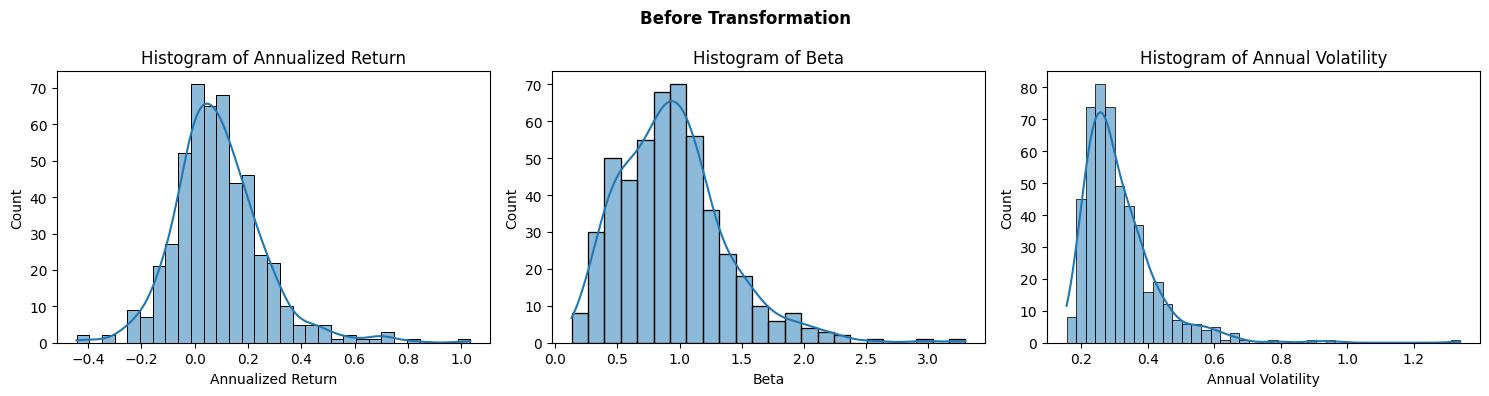

Skipped Annualized Return (contains zero or negative values)
Log transformation applied to: Beta
Log transformation applied to: Annual Volatility


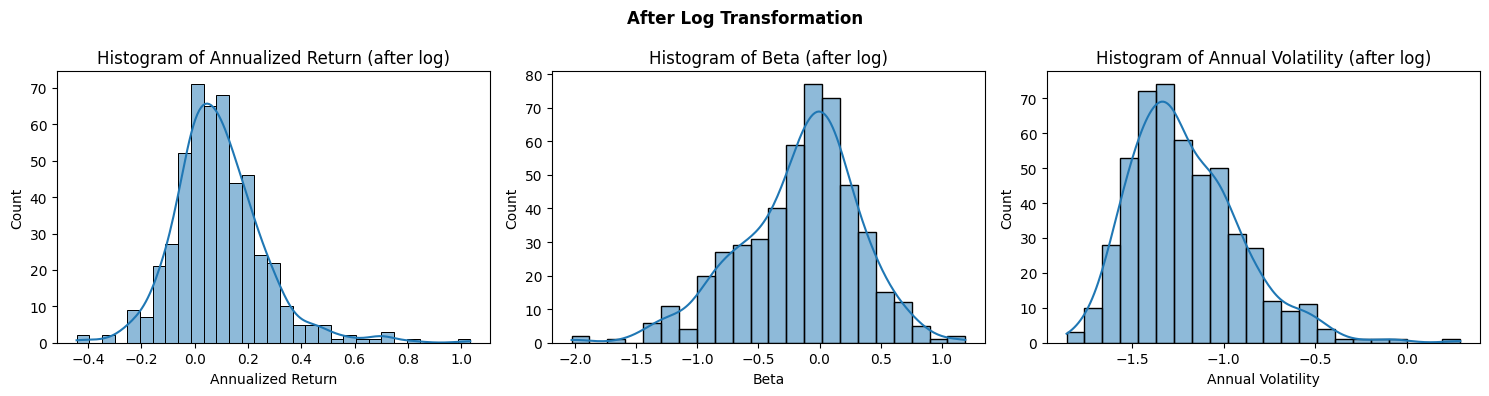


Scaling complete. X_scaled shape: (495, 3)


In [19]:
# ── CELL 4: Manage Skewness and Scaling ───────────────────────────────────

# --- Step 1: Visualise skewness BEFORE transformation ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(FEATURES):
    sns.histplot(data=X_raw, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col}')
plt.suptitle('Before Transformation', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Step 2: Apply log transformation to skewed features ---
# log transformation can only be applied if all values are positive
X_transformed = X_raw.copy()

for col in FEATURES:
    if X_transformed[col].min() > 0:
        X_transformed[col] = np.log(X_transformed[col])
        print(f'Log transformation applied to: {col}')
    else:
        print(f'Skipped {col} (contains zero or negative values)')

# --- Step 3: Visualise AFTER transformation ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(FEATURES):
    sns.histplot(data=X_transformed, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Histogram of {col} (after log)')
plt.suptitle('After Log Transformation', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Step 4: Standard Scaling (zero mean, unit variance) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)
print('\nScaling complete. X_scaled shape:', X_scaled.shape)

Silhouette scores: [np.float64(0.33025675654732894), np.float64(0.2907580697626487), np.float64(0.2652873760747682), np.float64(0.27024337732674786), np.float64(0.2738521814042675), np.float64(0.2727548426410276), np.float64(0.24639529376598235), np.float64(0.2545632903195267)]
Average silhouette score: 0.2755


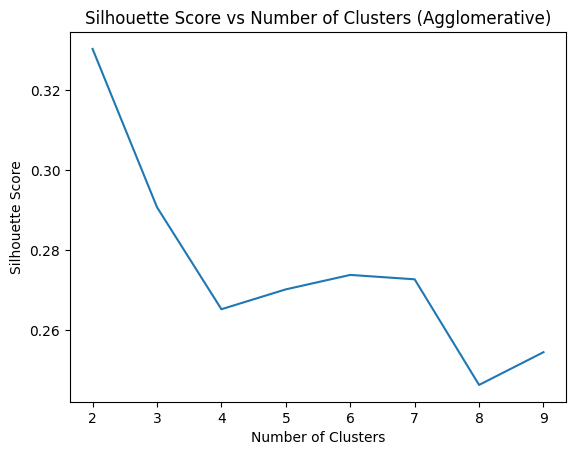

In [31]:
# ── CELL 5: Agglomerative Clustering - Silhouette to Find Best N ──────────
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for n_clusters in range_n_clusters:
    agglom = AgglomerativeClustering(n_clusters=n_clusters)
    agglom.fit(X_scaled)
    labels = agglom.labels_
    scores.append(silhouette_score(X_scaled, labels))

average = sum(scores) / len(scores)
print('Silhouette scores:', scores)
print('Average silhouette score:', round(average, 4))

plt.plot(range_n_clusters, scores)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters (Agglomerative)')
plt.show()

In [32]:
# ── CELL 6: Fit Agglomerative Model with Best N ───────────────────────────
best_n_agg = range_n_clusters[scores.index(max(scores))]
print(f'Best N: {best_n_agg}')

agglom = AgglomerativeClustering(n_clusters=best_n_agg)
cluster_labels = agglom.fit_predict(X_scaled)
df['Agg_Cluster'] = cluster_labels

print('\nCluster sizes:')
for i in range(best_n_agg):
    print(f'Cluster {i+1} has {list(cluster_labels).count(i)} observations')

print('\nCluster means:')
display(df.groupby('Agg_Cluster')[FEATURES].mean().round(4))

Best N: 2

Cluster sizes:
Cluster 1 has 171 observations
Cluster 2 has 324 observations

Cluster means:


,Annualized Return,Beta,Annual Volatility
Agg_Cluster,,,
0,0.1049,1.3657,0.4219
1,0.0833,0.7223,0.2572


Cluster 1 has 171 observations
Cluster 2 has 324 observations


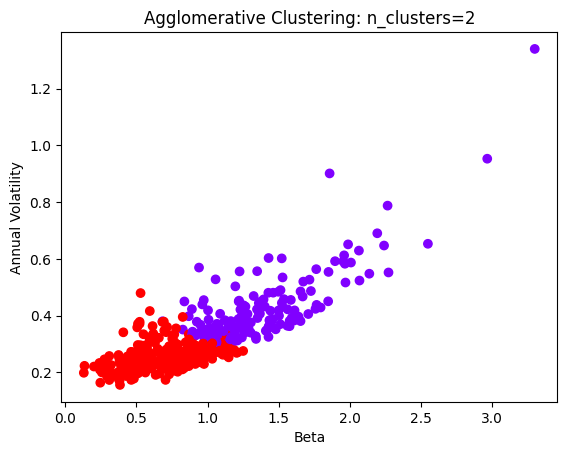

Cluster 1 has 324 observations
Cluster 2 has 52 observations
Cluster 3 has 119 observations


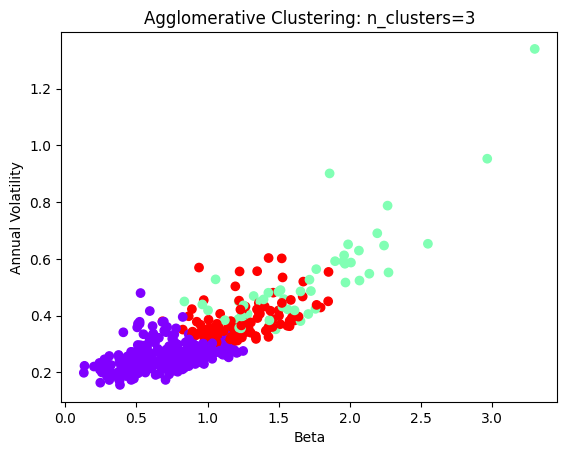

Cluster 1 has 248 observations
Cluster 2 has 52 observations
Cluster 3 has 119 observations
Cluster 4 has 76 observations


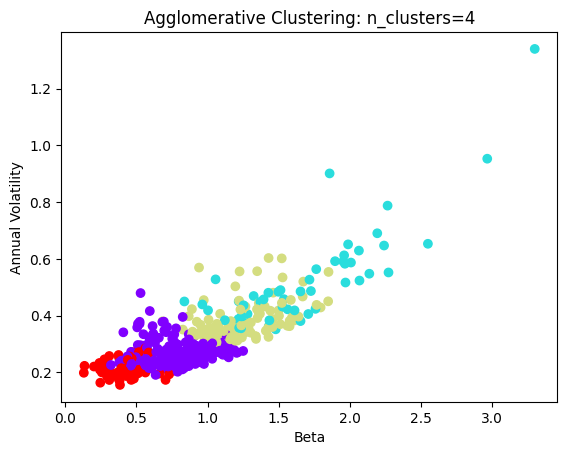

Cluster 1 has 52 observations
Cluster 2 has 118 observations
Cluster 3 has 119 observations
Cluster 4 has 76 observations
Cluster 5 has 130 observations


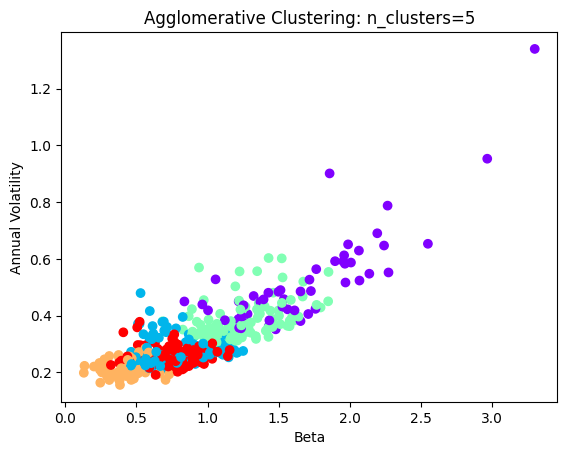

Cluster 1 has 119 observations
Cluster 2 has 118 observations
Cluster 3 has 44 observations
Cluster 4 has 76 observations
Cluster 5 has 130 observations
Cluster 6 has 8 observations


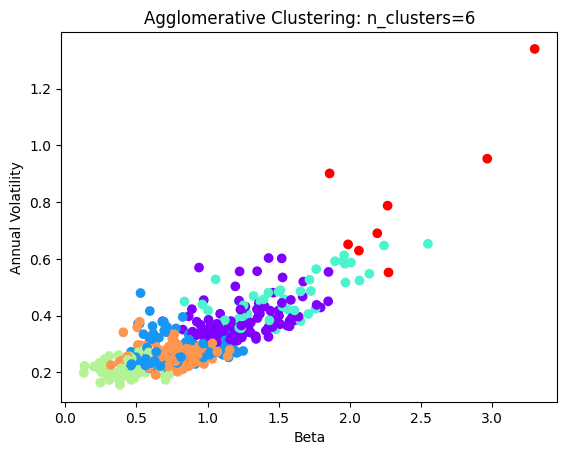

Cluster 1 has 118 observations
Cluster 2 has 130 observations
Cluster 3 has 44 observations
Cluster 4 has 76 observations
Cluster 5 has 105 observations
Cluster 6 has 8 observations
Cluster 7 has 14 observations


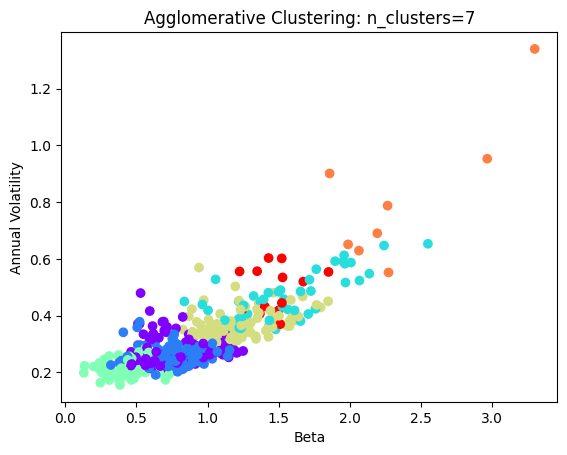

Cluster 1 has 130 observations
Cluster 2 has 105 observations
Cluster 3 has 44 observations
Cluster 4 has 76 observations
Cluster 5 has 72 observations
Cluster 6 has 8 observations
Cluster 7 has 14 observations
Cluster 8 has 46 observations


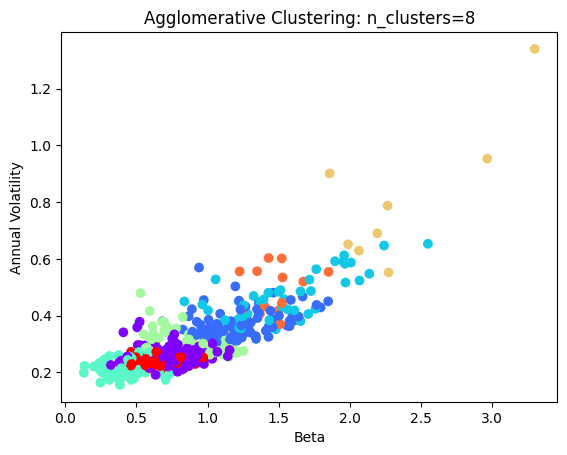

Cluster 1 has 44 observations
Cluster 2 has 105 observations
Cluster 3 has 113 observations
Cluster 4 has 76 observations
Cluster 5 has 72 observations
Cluster 6 has 8 observations
Cluster 7 has 14 observations
Cluster 8 has 46 observations
Cluster 9 has 17 observations


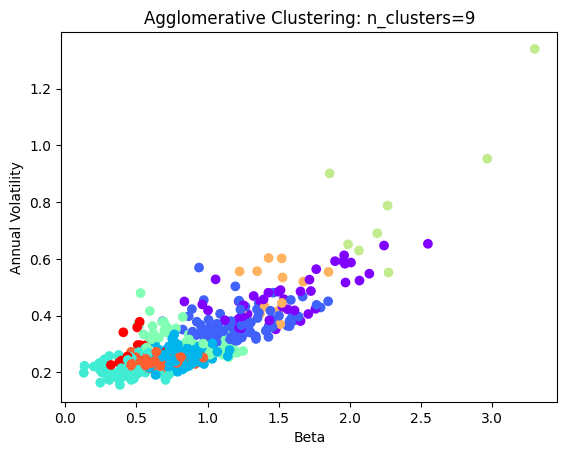

In [33]:
# ── CELL 7: Scatter Plot - Agglomerative Clusters ─────────────────────────
import numpy as np

for n_clusters in range_n_clusters:
    model = AgglomerativeClustering(n_clusters=n_clusters)
    labels = model.fit_predict(X_scaled)

    plt.scatter(df['Beta'], df['Annual Volatility'], c=labels, cmap='rainbow')
    plt.xlabel('Beta')
    plt.ylabel('Annual Volatility')
    plt.title(f'Agglomerative Clustering: n_clusters={n_clusters}')

    cluster_counts = np.bincount(labels)
    for i in range(n_clusters):
        print(f'Cluster {i+1} has {cluster_counts[i]} observations')

    plt.show()


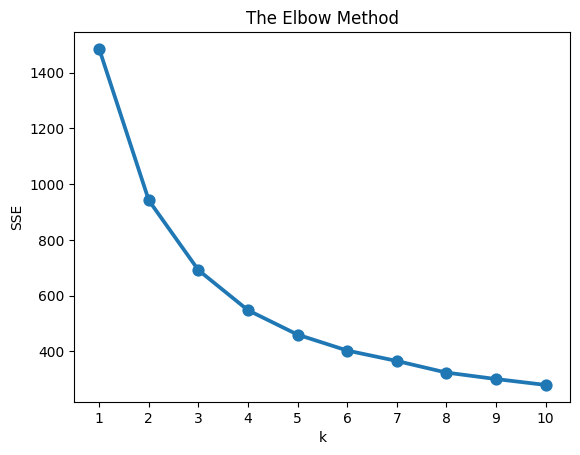

In [34]:
# ═══════════════════════════════════════════════════════════════════════════
# K-MEANS CLUSTERING
# ═══════════════════════════════════════════════════════════════════════════

# ── CELL 8: Elbow Method to Find Best K ───────────────────────────────────
from sklearn.cluster import KMeans

sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse[k] = kmeans.inertia_

plt.title('The Elbow Method')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [35]:
# ── CELL 9: Fit Final K-Means Model ───────────────────────────────────────
best_k = 4  # update based on elbow plot observation

model = KMeans(n_clusters=best_k, random_state=42)
model.fit(X_scaled)
df['Cluster'] = model.labels_

# Cluster profile - mean of Beta and Annual Volatility per cluster
print('Cluster profiles (Beta and Annual Volatility):')
display(df.groupby('Cluster').agg({
    'Annualized Return': 'mean',
    'Beta': 'mean',
    'Annual Volatility': ['mean', 'count']
}).round(4))

Cluster profiles (Beta and Annual Volatility):


Annualized Return    Beta Annual Volatility      
                     mean    mean              mean count
Cluster                                                  
0                 -0.0443  1.2351            0.3902   109
1                  0.3908  1.5768            0.4954    55
2                  0.1028  0.8884            0.2767   224
3                  0.0490  0.4409            0.2216   107

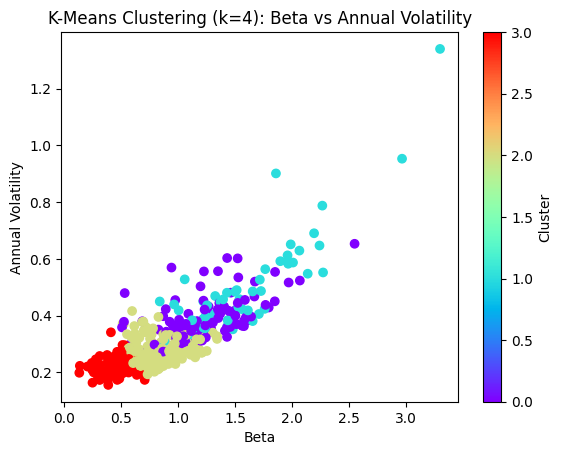

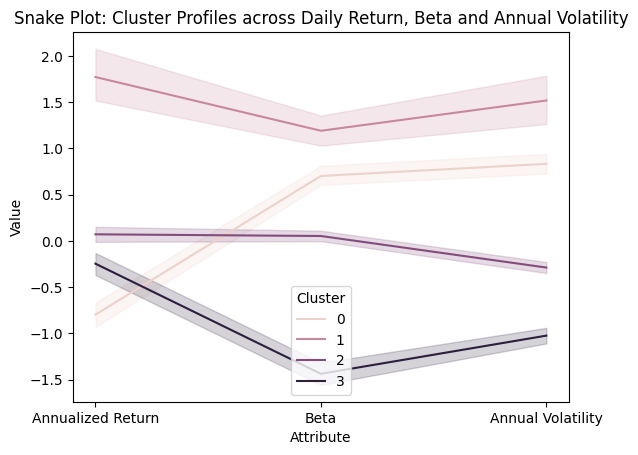

In [36]:
# ── CELL 10: Scatter Plot - K-Means Clusters ──────────────────────────────
plt.scatter(df['Beta'], df['Annual Volatility'], c=df['Cluster'], cmap='rainbow')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title(f'K-Means Clustering (k={best_k}): Beta vs Annual Volatility')
plt.colorbar(label='Cluster')
plt.show()

# Snake plot to show how clusters differ across all three dimensions
df_normalized = pd.DataFrame(X_scaled, columns=FEATURES)
df_normalized['Cluster'] = model.labels_

df_nor_melt = pd.melt(df_normalized.reset_index(),
                      id_vars=['index', 'Cluster'],
                      value_vars=FEATURES,
                      var_name='Attribute',
                      value_name='Value')

sns.lineplot(x='Attribute', y='Value', hue='Cluster', data=df_nor_melt)
plt.title('Snake Plot: Cluster Profiles across Daily Return, Beta and Annual Volatility')
plt.show()